**生成式AI的使用 (Generative AI Use)**：就本次作业而言，生成式AI的使用同样受关于协作的政策约束。与其他合作者一样，每个学生必须独立于（与AI）交互的输出写下解答，并且在提交的作业中应包含说明协作性质的附注。使用生成式AI工具来实质性地完成作业的大部分内容不符合本次作业的精神，这一行为将违反[荣誉守则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [5]:
# 将你的 Google Drive 挂载到 Colab 虚拟机上。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: 输入你在 Drive 中保存解压后作业文件夹的文件夹名称，
# 例如 'cs231n/assignments/assignment2/'
#FOLDERNAME = 'cs231n/assignments/assignment2/'
#assert FOLDERNAME is not None, "[!] 输入文件夹名称。([!] Enter the foldername.)"

# 现在我们已经挂载了你的 Drive，这确保了
# Colab 虚拟机的 Python 解释器能够从中加载 python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果你的 Drive 中尚未存在 CIFAR-10 数据集，
# 以下代码会将其下载到你的 Drive 中。
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
#!bash get_datasets.sh
#%cd /content/drive/My\ Drive/$FOLDERNAME

# Dropout (随机失活)
Dropout [1] 是一种用于正则化神经网络的技术，通过在前向传播的过程中随机将某些层输出的激活值设为零来实现。在本次练习中，你将实现一个 Dropout 层，并修改你的全连接网络结构，使其能够选择性地使用 Dropout 功能。

[1] [Geoffrey E. Hinton et al, "Improving neural networks by preventing co-adaptation of feature detectors", arXiv 2012](https://arxiv.org/abs/1207.0580)

In [6]:
# 设置单元格。
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # 设置绘图的默认大小。
plt.rcParams["font.family"] = "SimHei"  # 设置字体以支持中文显示
plt.rcParams["axes.unicode_minus"] = False  # 解决负号 '-' 显示为方块的问题
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """返回相对误差 (Returns relative error.)。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# 加载（经过预处理的）CIFAR-10 数据。
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# Dropout：前向传播
在 `cs231n/layers.py` 文件中实现 Dropout 的前向传播。由于 Dropout 在训练和测试阶段的行为完全不同，请确保你针对这两种模式进行了分别实现。

完成后，运行下方的代码单元格来测试你写的代码逻辑。

In [8]:
np.random.seed(231)
x = np.random.randn(500, 500) + 10

for p in [0.25, 0.4, 0.7]:
    out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
    out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})

    print('带 p 运行检测中 (Running tests with p) = ', p)
    print('输入的均值 (Mean of input): ', x.mean())
    print('训练阶段输出的均值 (Mean of train-time output): ', out.mean())
    print('测试阶段输出的均值 (Mean of test-time output): ', out_test.mean())
    print('训练阶段输出归零元素的比例分数 (Fraction of train-time output set to zero): ', (out == 0).mean())
    print('测试阶段输出归零元素的比例分数 (Fraction of test-time output set to zero): ', (out_test == 0).mean())
    print()

带 p 运行检测中 (Running tests with p) =  0.25
输入的均值 (Mean of input):  10.0002078784775
训练阶段输出的均值 (Mean of train-time output):  10.014059116977283
测试阶段输出的均值 (Mean of test-time output):  10.0002078784775
训练阶段输出归零元素的比例分数 (Fraction of train-time output set to zero):  0.749784
测试阶段输出归零元素的比例分数 (Fraction of test-time output set to zero):  0.0

带 p 运行检测中 (Running tests with p) =  0.4
输入的均值 (Mean of input):  10.0002078784775
训练阶段输出的均值 (Mean of train-time output):  9.977917658761159
测试阶段输出的均值 (Mean of test-time output):  10.0002078784775
训练阶段输出归零元素的比例分数 (Fraction of train-time output set to zero):  0.600796
测试阶段输出归零元素的比例分数 (Fraction of test-time output set to zero):  0.0

带 p 运行检测中 (Running tests with p) =  0.7
输入的均值 (Mean of input):  10.0002078784775
训练阶段输出的均值 (Mean of train-time output):  9.987811912159428
测试阶段输出的均值 (Mean of test-time output):  10.0002078784775
训练阶段输出归零元素的比例分数 (Fraction of train-time output set to zero):  0.30074
测试阶段输出归零元素的比例分数 (Fraction of test-time output set to zero):  0.0



# Dropout：反向传播
在 `cs231n/layers.py` 文件中，实现针对 Dropout 函数的反向传播过程。完成之后，运行下方的单元格来进行梯度检查，以使用数值梯度来核验你的代码是否正确。

In [9]:
np.random.seed(231)
x = np.random.randn(10, 10) + 10
dout = np.random.randn(*x.shape)

dropout_param = {'mode': 'train', 'p': 0.2, 'seed': 123}
out, cache = dropout_forward(x, dropout_param)
dx = dropout_backward(dout, cache)
dx_num = eval_numerical_gradient_array(lambda xx: dropout_forward(xx, dropout_param)[0], x, dout)

# 误差应在 e-10 或更小的量级左右 (Error should be around e-10 or less.)
print('dx 相对误差 (dx relative error): ', rel_error(dx, dx_num))

dx 相对误差 (dx relative error):  5.44560814873387e-11


## 内联问题 1 (Inline Question 1)：
如果我们在 Dropout 层中没有除以保留概率 `p`（即没有使用倒置 Dropout），会发生什么情况？为什么会发生这种情况？

## 解答：
如果这样的话，模型在测试阶段的性能和准确率会下降甚至失效。
原因是训练和测试的输出信号期望不一样。训练的时候由于一部分神经元被丢弃了，导致下一层接收到的信号总量会比较小，在测试的时候传入的信号又是完整的，就导致测试时的输入信号远大于网络经过训练所习惯的信号量级，导致输出错误的预测结果。

# 含 Dropout 的全连接网络
打开 `cs231n/classifiers/fc_net.py` 文件，修改你的代码以支持 Dropout。具体而言，如果网络参数中传入的 `dropout_keep_ratio` 数值不等于 1（1 代表默认的 100% 保留），那么你需要在这每一层的 ReLU 步骤之后添加一个 Dropout 层。完成后，运行下方的单元格来对加入了 Dropout 层的网络进行梯度检查与验证。

In [10]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for dropout_keep_ratio in [1, 0.75, 0.5]:
    print('执行 dropout 参数检验 (Running check with dropout) = ', dropout_keep_ratio)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        weight_scale=5e-2,
        dtype=np.float64,
        dropout_keep_ratio=dropout_keep_ratio,
        seed=123
    )

    loss, grads = model.loss(X, y)
    print('初始阶段给出的损失 (Initial loss): ', loss)

    # 相对误差应该在 e-6 或更小的量级左右 (Relative errors should be around e-6 or less.)
    # 并且请注意，当 dropout_keep_ratio=1 时，W2 的误差在 e-5 左右也是正常的。(Note that it's fine if for dropout_keep_ratio=1 you have W2 error be on the order of e-5.)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s 的相对误差 (relative error): %.2e' % (name, rel_error(grad_num, grads[name])))
    print()

执行 dropout 参数检验 (Running check with dropout) =  1
初始阶段给出的损失 (Initial loss):  2.300479089768492
W1 的相对误差 (relative error): 1.03e-07
W2 的相对误差 (relative error): 2.21e-05
W3 的相对误差 (relative error): 4.56e-07
b1 的相对误差 (relative error): 4.66e-09
b2 的相对误差 (relative error): 2.09e-09
b3 的相对误差 (relative error): 1.69e-10

执行 dropout 参数检验 (Running check with dropout) =  0.75
初始阶段给出的损失 (Initial loss):  2.302371489704412
W1 的相对误差 (relative error): 1.85e-07
W2 的相对误差 (relative error): 2.15e-06
W3 的相对误差 (relative error): 4.56e-08
b1 的相对误差 (relative error): 1.16e-08
b2 的相对误差 (relative error): 1.82e-09
b3 的相对误差 (relative error): 1.48e-10

执行 dropout 参数检验 (Running check with dropout) =  0.5
初始阶段给出的损失 (Initial loss):  2.30427592207859
W1 的相对误差 (relative error): 3.11e-07
W2 的相对误差 (relative error): 2.48e-08
W3 的相对误差 (relative error): 6.43e-08
b1 的相对误差 (relative error): 5.37e-09
b2 的相对误差 (relative error): 1.91e-09
b3 的相对误差 (relative error): 1.85e-10



# 正则化实验 (Regularization Experiment)
在这个实验环节，我们将使用 500 个训练样本来训练两个两层神经网络：一个没有使用 Dropout，另一个使用了保留参数为 0.25 的 Dropout。随后，我们将绘制它们在训练过程中的训练准确率和验证准确率随 epoch 变化的图表，以直观地对比两种网络的表现。

In [12]:
# 训练两个结构相同的网络，一个使用 dropout，另一个不使用。(Train two identical nets, one with dropout and one without.)
np.random.seed(231)
num_train = 500
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

solvers = {}
dropout_choices = [1, 0.25]
for dropout_keep_ratio in dropout_choices:
    model = FullyConnectedNet(
        [500],
        dropout_keep_ratio=dropout_keep_ratio
    )
    print(dropout_keep_ratio)

    solver = Solver(
        model,
        small_data,
        num_epochs=25,
        batch_size=100,
        update_rule='adam',
        optim_config={'learning_rate': 5e-4,},
        verbose=True,
        print_every=100
    )
    solver.train()
    solvers[dropout_keep_ratio] = solver
    print()

1
(Iteration 1 / 125) loss: 7.856642
(Epoch 0 / 25) train acc: 0.260000; val_acc: 0.184000
(Epoch 1 / 25) train acc: 0.416000; val_acc: 0.258000
(Epoch 2 / 25) train acc: 0.482000; val_acc: 0.276000
(Epoch 3 / 25) train acc: 0.532000; val_acc: 0.277000
(Epoch 4 / 25) train acc: 0.600000; val_acc: 0.271000
(Epoch 5 / 25) train acc: 0.708000; val_acc: 0.299000
(Epoch 6 / 25) train acc: 0.722000; val_acc: 0.282000
(Epoch 7 / 25) train acc: 0.832000; val_acc: 0.255000
(Epoch 8 / 25) train acc: 0.878000; val_acc: 0.269000
(Epoch 9 / 25) train acc: 0.902000; val_acc: 0.275000
(Epoch 10 / 25) train acc: 0.888000; val_acc: 0.261000
(Epoch 11 / 25) train acc: 0.926000; val_acc: 0.277000
(Epoch 12 / 25) train acc: 0.960000; val_acc: 0.303000
(Epoch 13 / 25) train acc: 0.962000; val_acc: 0.306000
(Epoch 14 / 25) train acc: 0.966000; val_acc: 0.309000
(Epoch 15 / 25) train acc: 0.982000; val_acc: 0.288000
(Epoch 16 / 25) train acc: 0.982000; val_acc: 0.302000
(Epoch 17 / 25) train acc: 0.978000; v

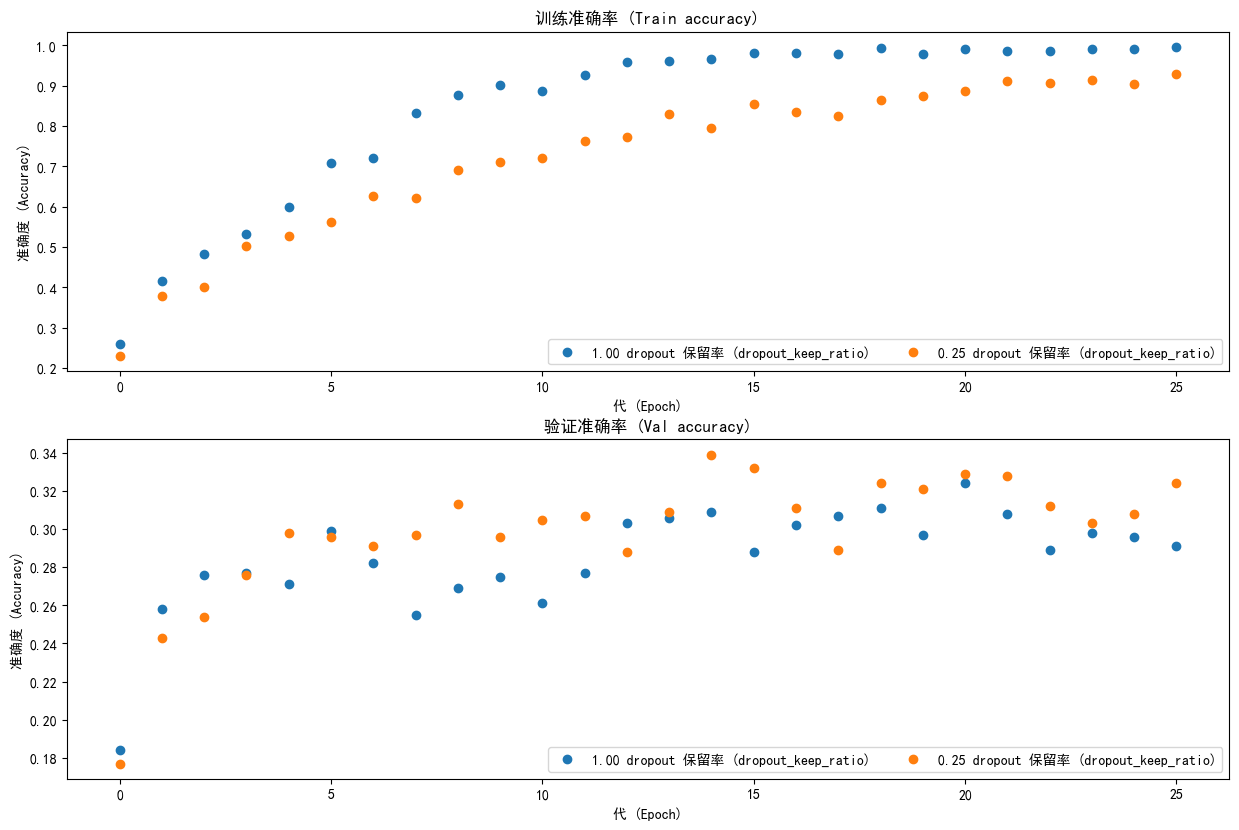

: 

In [ ]:
# 绘制两个模型在训练和验证集上的准确率。(Plot train and validation accuracies of the two models.)
train_accs = []
val_accs = []
for dropout_keep_ratio in dropout_choices:
    solver = solvers[dropout_keep_ratio]
    train_accs.append(solver.train_acc_history[-1])
    val_accs.append(solver.val_acc_history[-1])

plt.subplot(3, 1, 1)
for dropout_keep_ratio in dropout_choices:
    plt.plot(
        solvers[dropout_keep_ratio].train_acc_history, 'o', label='%.2f dropout 保留率 (dropout_keep_ratio)' % dropout_keep_ratio)
plt.title('训练准确率 (Train accuracy)')
plt.xlabel('代 (Epoch)')
plt.ylabel('准确度 (Accuracy)')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
for dropout_keep_ratio in dropout_choices:
    plt.plot(
        solvers[dropout_keep_ratio].val_acc_history, 'o', label='%.2f dropout 保留率 (dropout_keep_ratio)' % dropout_keep_ratio)
plt.title('验证准确率 (Val accuracy)')
plt.xlabel('代 (Epoch)')
plt.ylabel('准确度 (Accuracy)')
plt.legend(ncol=2, loc='lower right')

plt.gcf().set_size_inches(15, 15)
plt.show()

## 内联问题 2 (Inline Question 2)：
对比使用了 dropout 和不使用 dropout 时记录到的验证和训练准确率结果，从这种对比结果来看，dropout 作为正则化方法起到了什么样的作用？

## 解答：
在训练准确率上，无dropout的模型学习率快，准确率也更高，很快就达到了1.0，带dropout的模型最终准确率只有0.9左右。
在验证准确率上，有dropout的模型在大部分时候比不带dropout的模型准确率要高。
dropout作为正则化方法，牺牲了一点训练集的准确率，换取了模型泛化能力的提升。